In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

In [3]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

In [4]:
client_versions_file = os.path.join(repo_dir, "data", "missed_slots_13164544_13166355", "client_versions.parquet")
client_versions_df = pd.read_parquet(client_versions_file)
client_versions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418324 entries, 0 to 418323
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   node_name                    418324 non-null  object        
 1   node_country                 418324 non-null  object        
 2   node_client_version          418324 non-null  object        
 3   node_client_implementation   418324 non-null  object        
 4   node_client_id               418324 non-null  object        
 5   remote_agent_implementation  418324 non-null  object        
 6   remote_agent_version         418324 non-null  object        
 7   remote_agent_version_major   418324 non-null  object        
 8   remote_agent_version_minor   418324 non-null  object        
 9   remote_agent_version_patch   418324 non-null  object        
 10  event_date_time              418324 non-null  datetime64[ns]
 11  remote_peer_id            

In [5]:
# Count how many remote_agent_implementation are prysm
prysm_count = (client_versions_df["remote_agent_implementation"] == "prysm").sum()
print(f"Number of prysm implementations: {prysm_count}")

Number of prysm implementations: 5138


In [6]:
# Remove rows where remote_agent_implementation is "unknown"
client_versions_filtered_df = client_versions_df[client_versions_df["remote_agent_implementation"] != "unknown"]
print(f"Original dataframe shape: {client_versions_df.shape}")
print(f"Filtered dataframe shape: {client_versions_filtered_df.shape}")
print(f"Removed {client_versions_df.shape[0] - client_versions_filtered_df.shape[0]} rows with 'unknown' remote_agent_implementation")

Original dataframe shape: (418324, 12)
Filtered dataframe shape: (26789, 12)
Removed 391535 rows with 'unknown' remote_agent_implementation


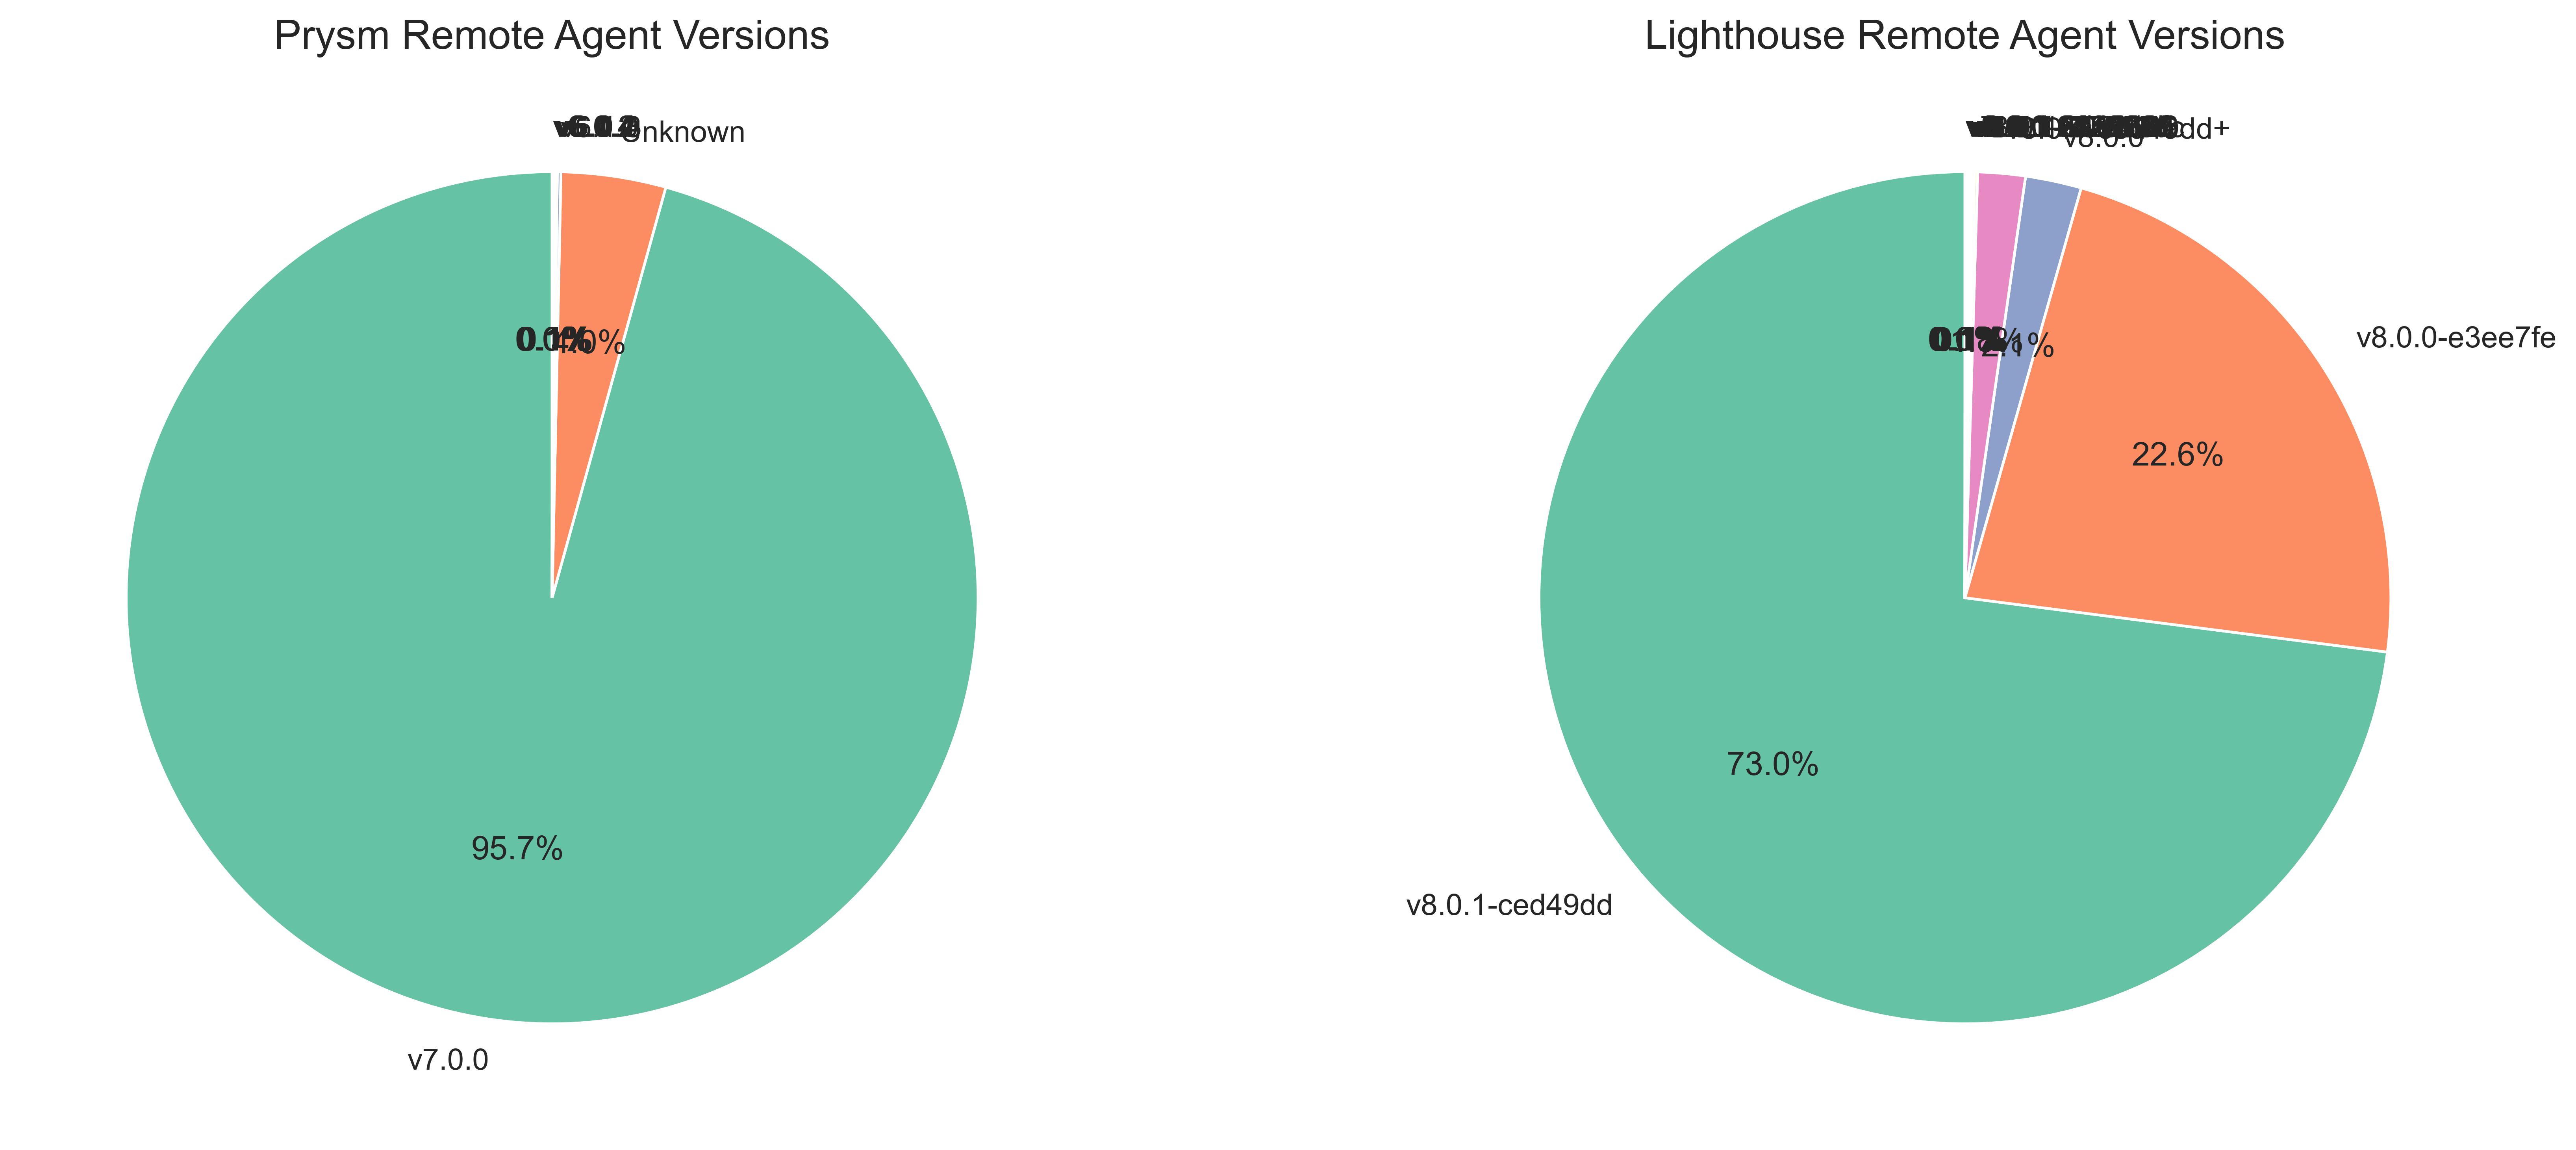

Prysm total entries: 5138
Lighthouse total entries: 10501
Prysm unique versions: 8
Lighthouse unique versions: 13


In [7]:
# Create pie charts for remote_agent_version for prysm and lighthouse
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Filter for prysm implementations
# 5ms batch reduction included in versions v6.1.3 and above
prysm_df = client_versions_filtered_df[client_versions_filtered_df["remote_agent_implementation"] == "prysm"]
prysm_version_counts = prysm_df["remote_agent_version"].value_counts()

# Create pie chart for prysm
ax1.pie(prysm_version_counts.values, labels=prysm_version_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title("Prysm Remote Agent Versions")

# Filter for lighthouse implementations
lighthouse_df = client_versions_filtered_df[client_versions_filtered_df["remote_agent_implementation"] == "lighthouse"]
lighthouse_version_counts = lighthouse_df["remote_agent_version"].value_counts()

# Create pie chart for lighthouse
ax2.pie(lighthouse_version_counts.values, labels=lighthouse_version_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title("Lighthouse Remote Agent Versions")

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Prysm total entries: {len(prysm_df)}")
print(f"Lighthouse total entries: {len(lighthouse_df)}")
print(f"Prysm unique versions: {len(prysm_version_counts)}")
print(f"Lighthouse unique versions: {len(lighthouse_version_counts)}")


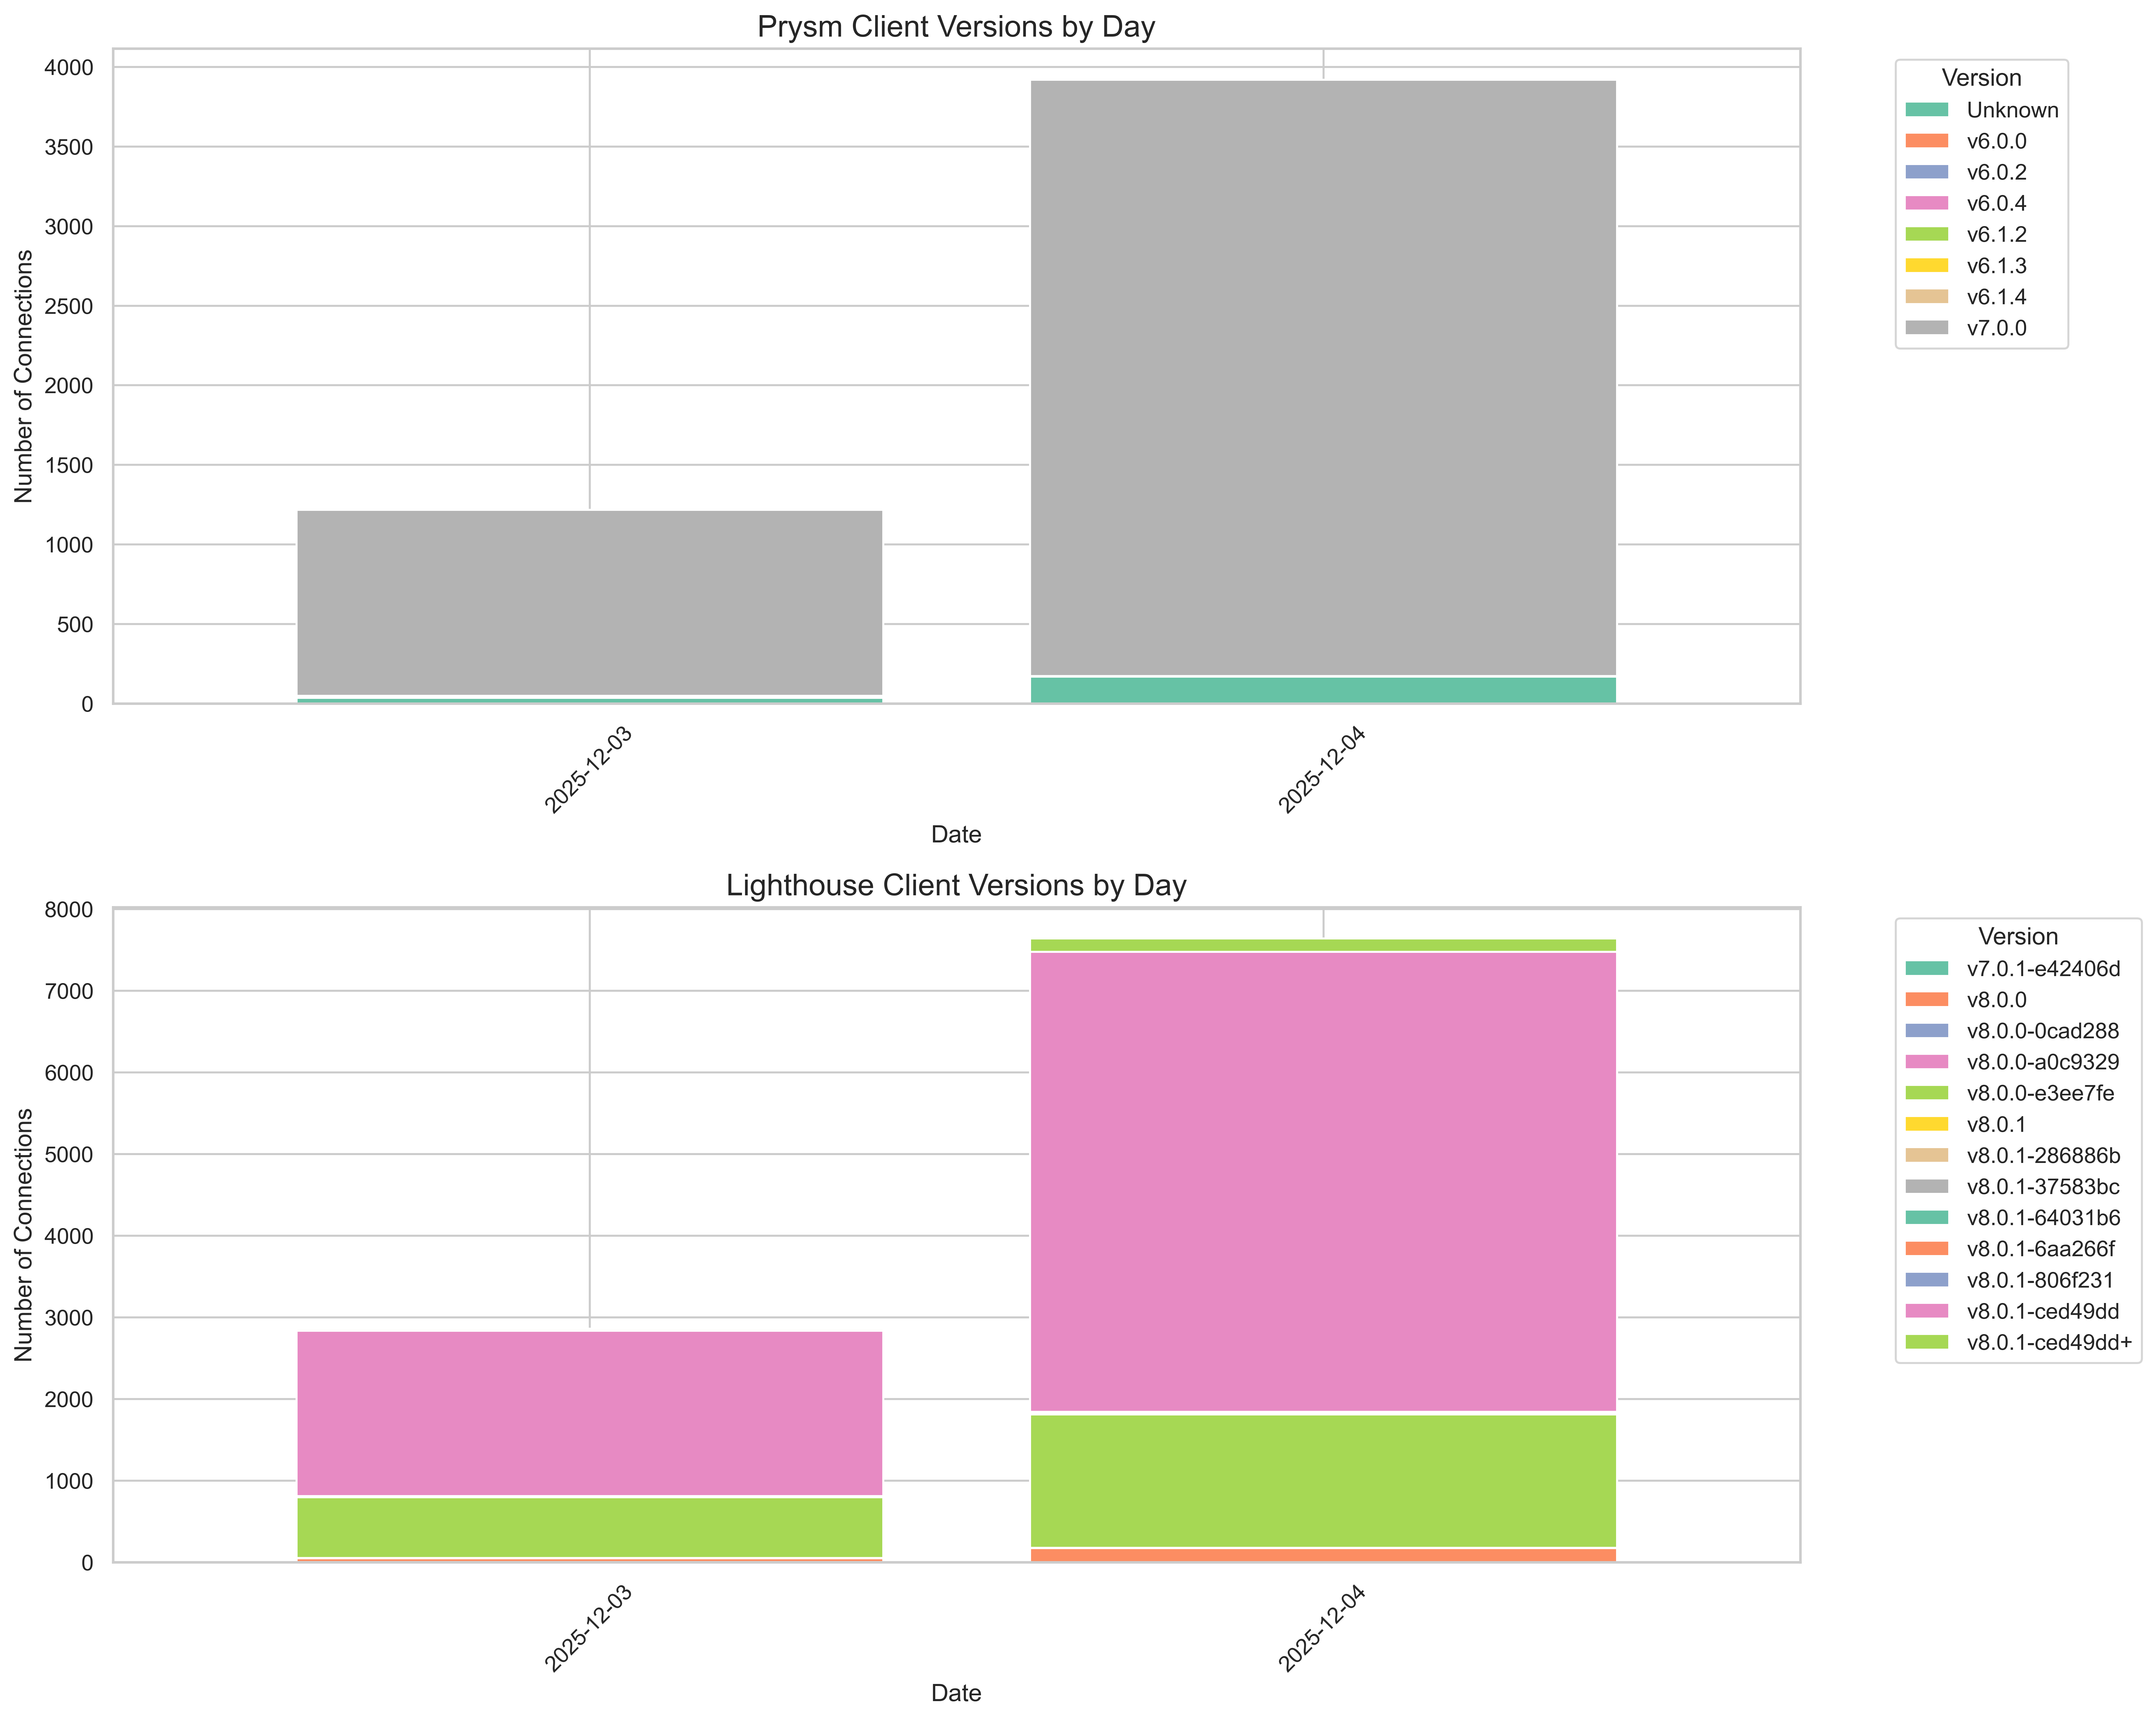

Prysm date range: 2025-12-03 to 2025-12-04
Lighthouse date range: 2025-12-03 to 2025-12-04
Prysm total daily entries: 2
Lighthouse total daily entries: 2


In [8]:
# Create histograms of client versions bucketed by day for prysm and lighthouse
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Convert event_date_time to datetime and extract date
client_versions_filtered_df['event_date'] = pd.to_datetime(client_versions_filtered_df['event_date_time']).dt.date

# Filter for prysm implementations
prysm_df = client_versions_filtered_df[client_versions_filtered_df["remote_agent_implementation"] == "prysm"]

# Create histogram for prysm versions by day
prysm_pivot = prysm_df.groupby(['event_date', 'remote_agent_version']).size().unstack(fill_value=0)
prysm_pivot.plot(kind='bar', stacked=True, ax=ax1, width=0.8)
ax1.set_title("Prysm Client Versions by Day")
ax1.set_xlabel("Date")
ax1.set_ylabel("Number of Connections")
ax1.legend(title="Version", bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Filter for lighthouse implementations
lighthouse_df = client_versions_filtered_df[client_versions_filtered_df["remote_agent_implementation"] == "lighthouse"]

# Create histogram for lighthouse versions by day
lighthouse_pivot = lighthouse_df.groupby(['event_date', 'remote_agent_version']).size().unstack(fill_value=0)
lighthouse_pivot.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
ax2.set_title("Lighthouse Client Versions by Day")
ax2.set_xlabel("Date")
ax2.set_ylabel("Number of Connections")
ax2.legend(title="Version", bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Prysm date range: {prysm_df['event_date'].min()} to {prysm_df['event_date'].max()}")
print(f"Lighthouse date range: {lighthouse_df['event_date'].min()} to {lighthouse_df['event_date'].max()}")
print(f"Prysm total daily entries: {len(prysm_pivot)}")
print(f"Lighthouse total daily entries: {len(lighthouse_pivot)}")


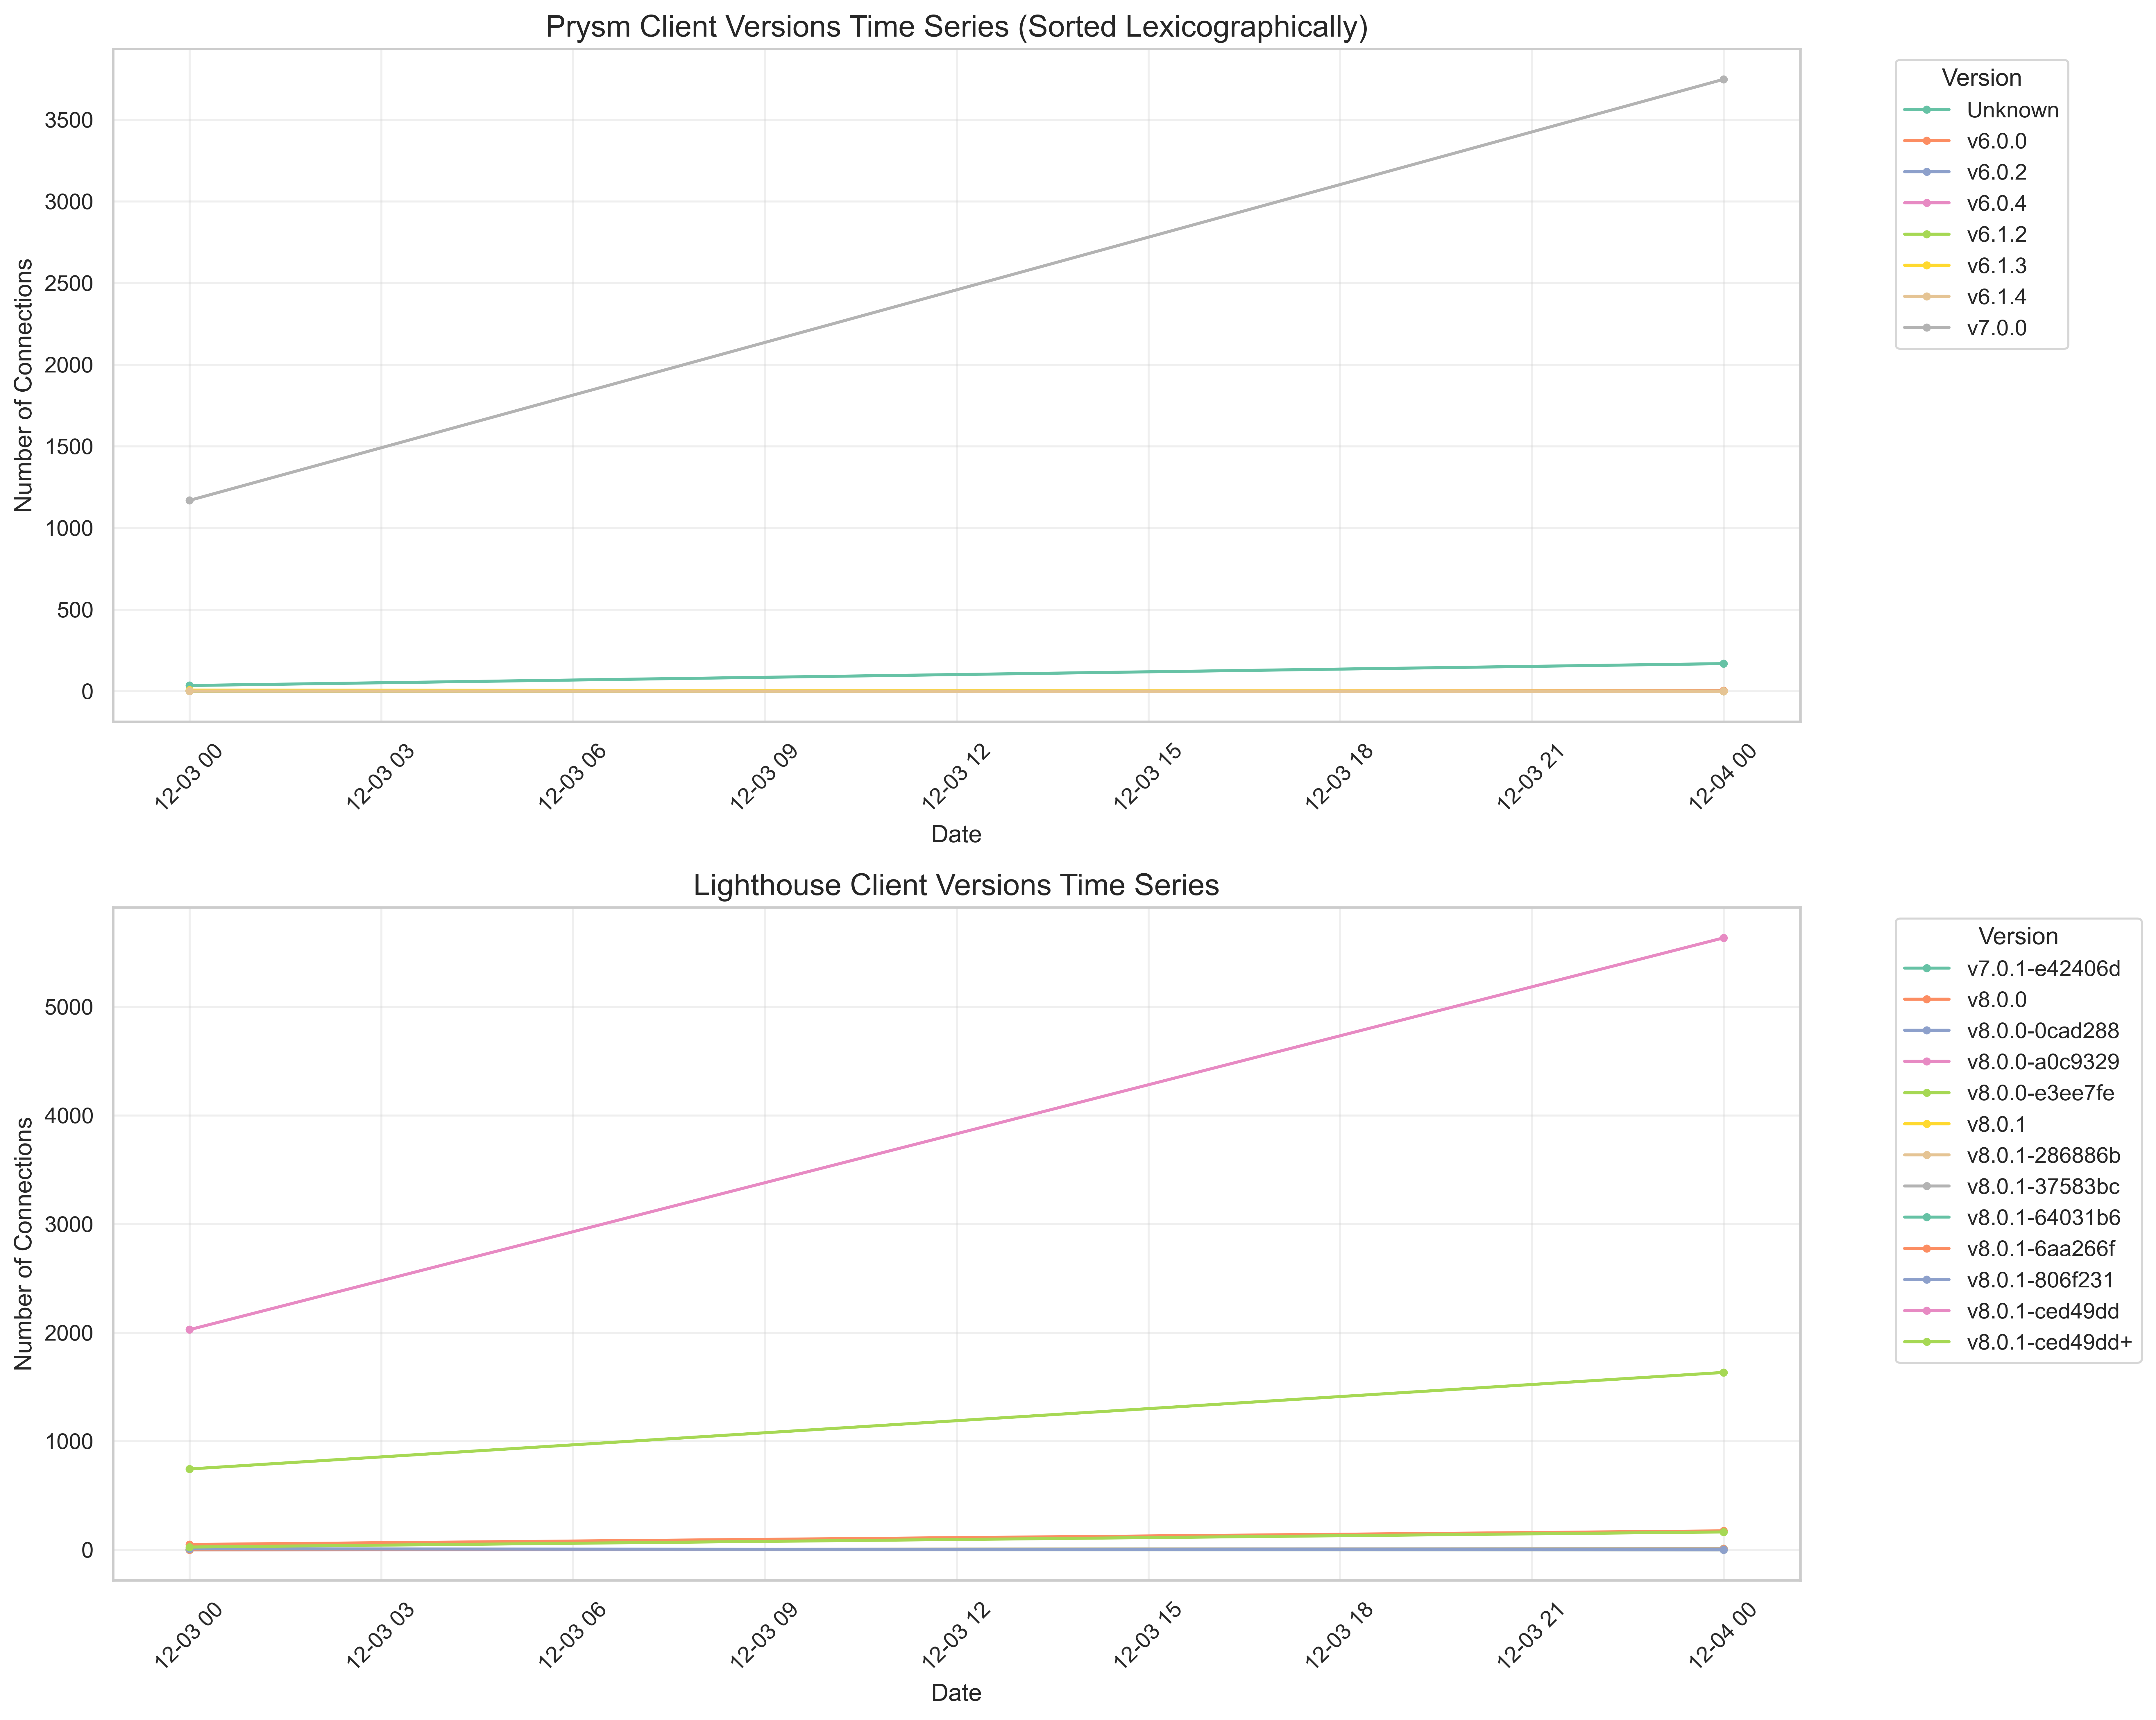

Prysm versions (sorted): ['Unknown', 'v6.0.0', 'v6.0.2', 'v6.0.4', 'v6.1.2', 'v6.1.3', 'v6.1.4', 'v7.0.0']
Lighthouse versions (sorted): ['v7.0.1-e42406d', 'v8.0.0', 'v8.0.0-0cad288', 'v8.0.0-a0c9329', 'v8.0.0-e3ee7fe', 'v8.0.1', 'v8.0.1-286886b', 'v8.0.1-37583bc', 'v8.0.1-64031b6', 'v8.0.1-6aa266f', 'v8.0.1-806f231', 'v8.0.1-ced49dd', 'v8.0.1-ced49dd+']
Prysm date range: 2025-12-03 to 2025-12-04
Lighthouse date range: 2025-12-03 to 2025-12-04


In [9]:
# Create time series of client versions bucketed by day and sorted lexicographically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Convert event_date_time to datetime and extract date
client_versions_filtered_df['event_date'] = pd.to_datetime(client_versions_filtered_df['event_date_time']).dt.date

# Filter for prysm implementations
prysm_df = client_versions_filtered_df[client_versions_filtered_df["remote_agent_implementation"] == "prysm"]

# Create time series for prysm versions by day
prysm_daily = prysm_df.groupby(['event_date', 'remote_agent_version']).size().unstack(fill_value=0)
# Sort columns (versions) lexicographically
prysm_daily = prysm_daily.reindex(sorted(prysm_daily.columns), axis=1)

# Plot prysm time series
for version in prysm_daily.columns:
    ax1.plot(prysm_daily.index, prysm_daily[version], label=version, marker='o', markersize=3)

ax1.set_title("Prysm Client Versions Time Series (Sorted Lexicographically)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Number of Connections")
ax1.legend(title="Version", bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Filter for lighthouse implementations
lighthouse_df = client_versions_filtered_df[client_versions_filtered_df["remote_agent_implementation"] == "lighthouse"]

# Create time series for lighthouse versions by day
lighthouse_daily = lighthouse_df.groupby(['event_date', 'remote_agent_version']).size().unstack(fill_value=0)
# Sort columns (versions) lexicographically
lighthouse_daily = lighthouse_daily.reindex(sorted(lighthouse_daily.columns), axis=1)

# Plot lighthouse time series
for version in lighthouse_daily.columns:
    ax2.plot(lighthouse_daily.index, lighthouse_daily[version], label=version, marker='o', markersize=3)

ax2.set_title("Lighthouse Client Versions Time Series")
ax2.set_xlabel("Date")
ax2.set_ylabel("Number of Connections")
ax2.legend(title="Version", bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Prysm versions (sorted): {sorted(prysm_daily.columns.tolist())}")
print(f"Lighthouse versions (sorted): {sorted(lighthouse_daily.columns.tolist())}")
print(f"Prysm date range: {prysm_daily.index.min()} to {prysm_daily.index.max()}")
print(f"Lighthouse date range: {lighthouse_daily.index.min()} to {lighthouse_daily.index.max()}")


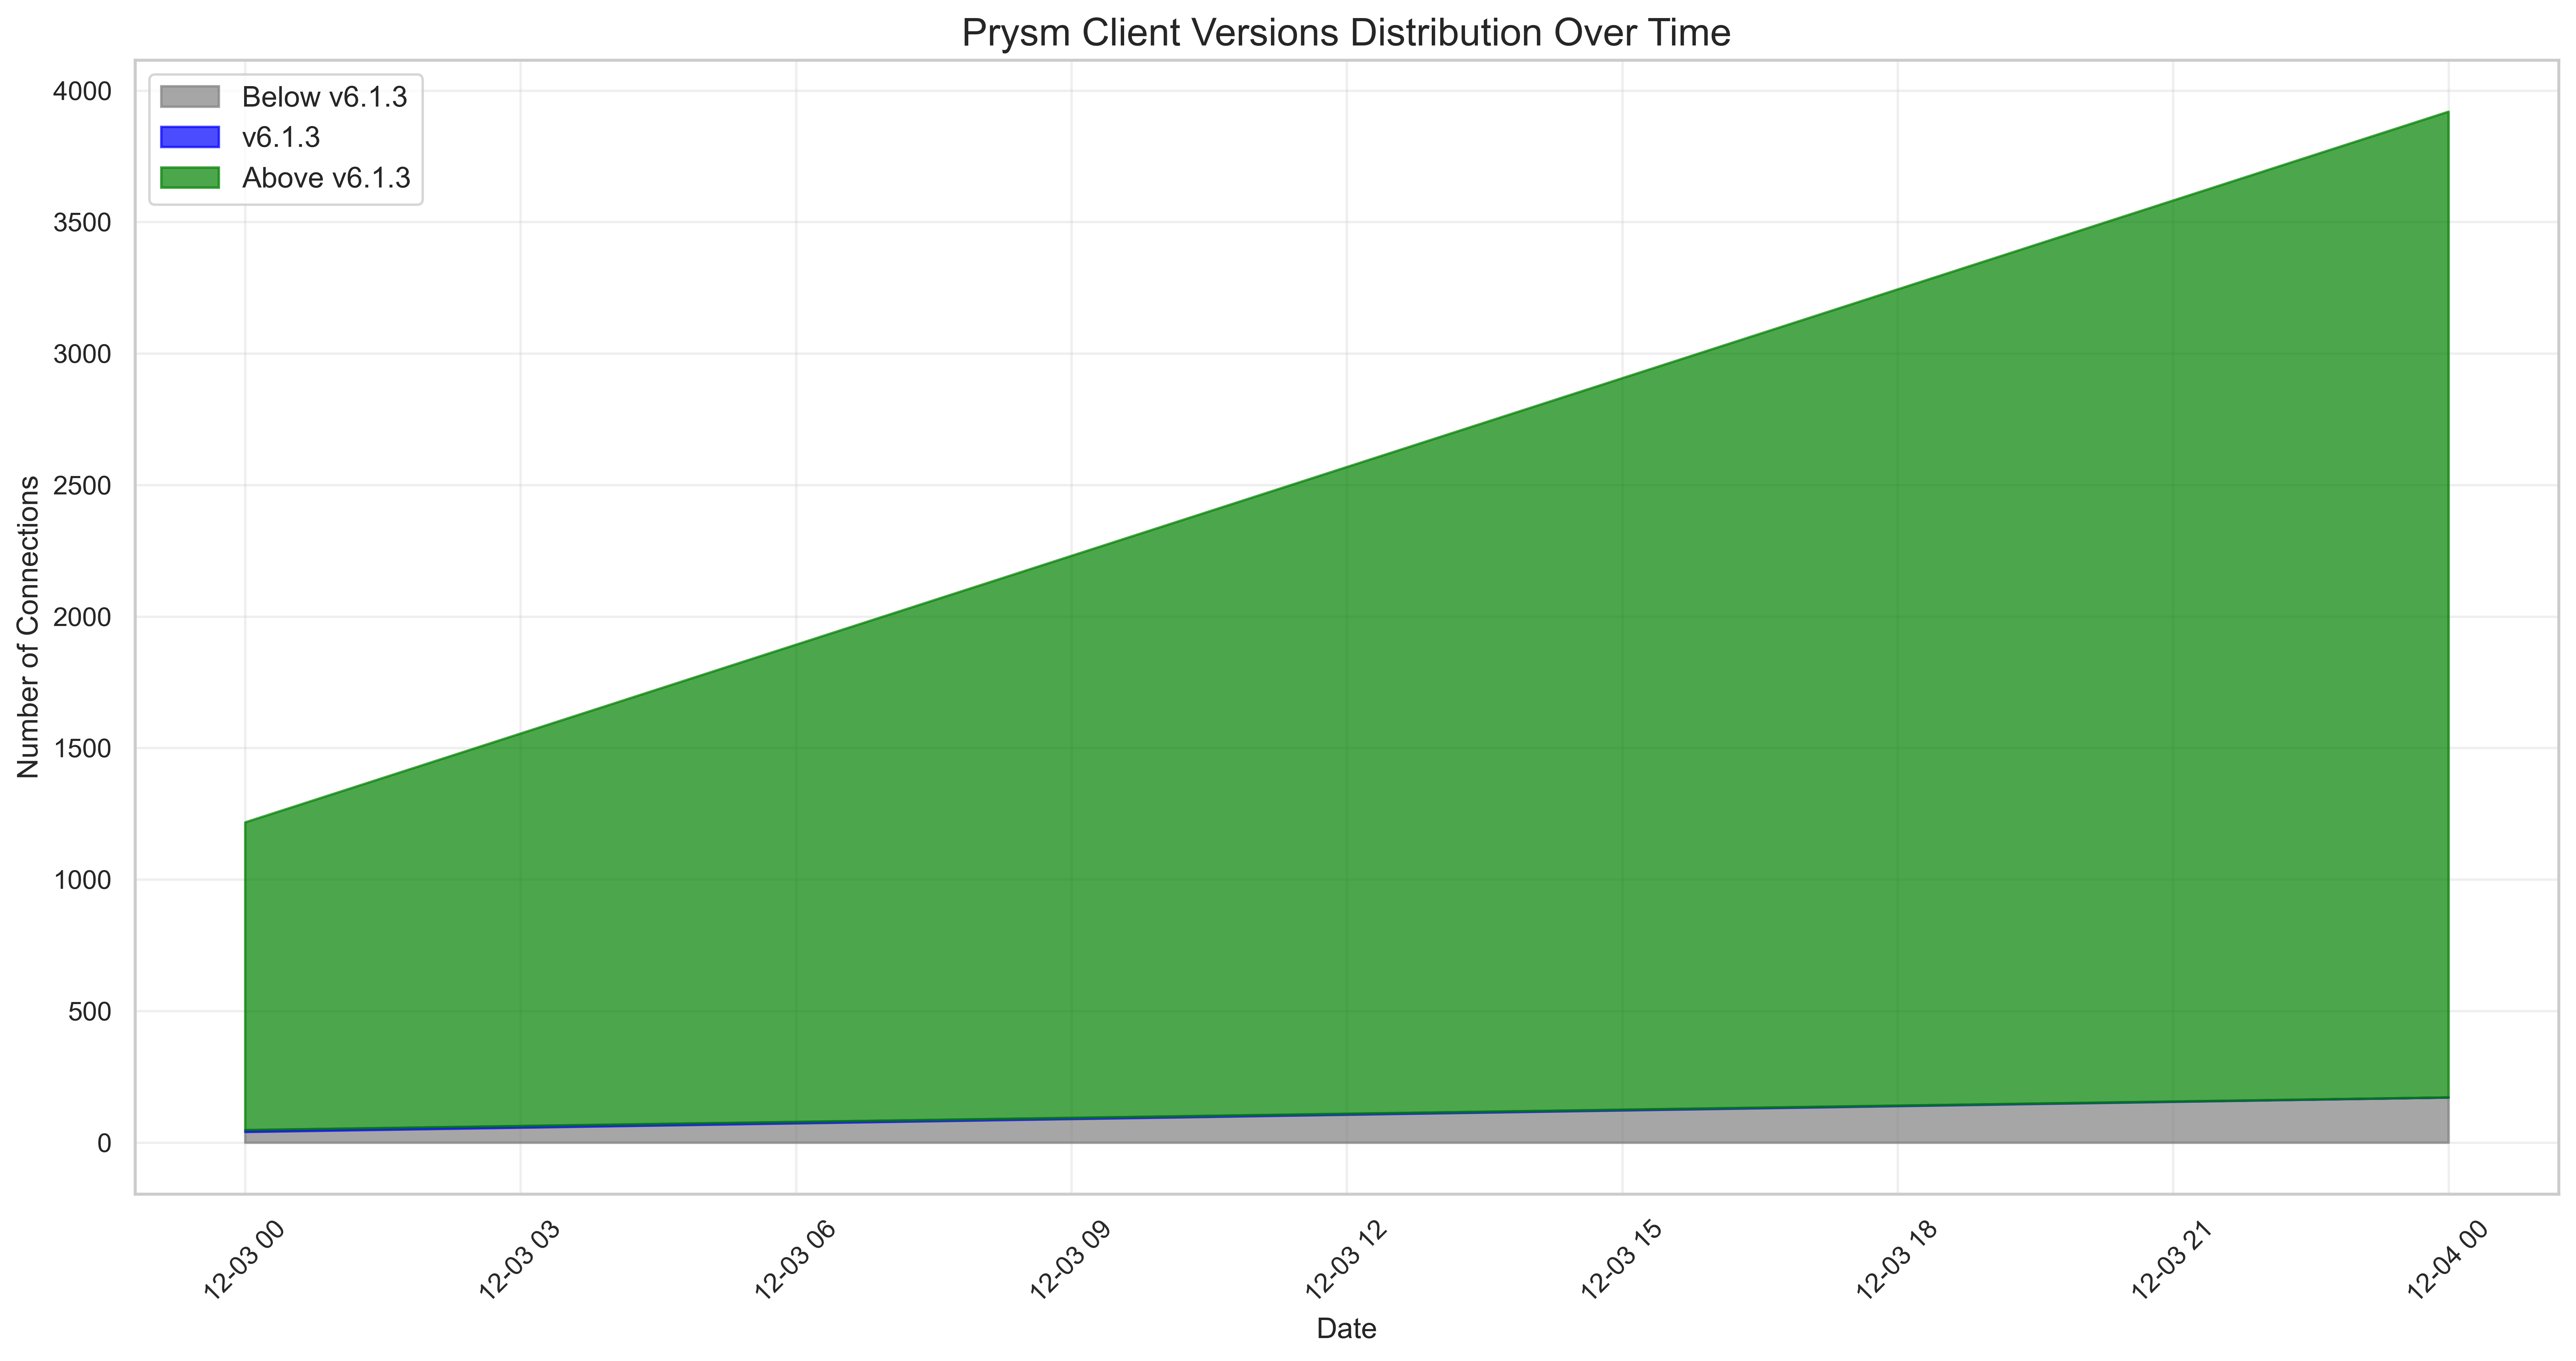

Version categorization:
Below v6.1.3 (gray): ['Unknown', 'v6.0.0', 'v6.0.2', 'v6.0.4', 'v6.1.2']
v6.1.3 (blue): ['v6.1.3']
Above v6.1.3 (green): ['v6.1.4', 'v7.0.0']


In [10]:
# Create area chart for Prysm versions with color coding
fig, ax = plt.subplots(figsize=(15, 8))

# Define version comparison function
def compare_versions(version_str):
    """Compare version with v6.1.3. Returns -1 if below, 0 if equal, 1 if above"""
    try:
        # Remove 'v' prefix if present and split by dots
        clean_version = version_str.lstrip('v')
        parts = clean_version.split('.')
        
        # Convert to integers for comparison (pad with zeros if needed)
        version_parts = [int(p) for p in parts[:3]]  # Take first 3 parts
        while len(version_parts) < 3:
            version_parts.append(0)
        
        target = [6, 1, 3]
        
        for i in range(3):
            if version_parts[i] < target[i]:
                return -1
            elif version_parts[i] > target[i]:
                return 1
        return 0
    except:
        # If parsing fails, treat as below target
        return -1

# Categorize versions
below_versions = []
target_version = []
above_versions = []

for version in prysm_daily.columns:
    comparison = compare_versions(version)
    if comparison < 0:
        below_versions.append(version)
    elif comparison == 0:
        target_version.append(version)
    else:
        above_versions.append(version)

# Create stacked area chart
# Start with below versions (gray)
if below_versions:
    below_data = prysm_daily[below_versions].sum(axis=1)
    ax.fill_between(prysm_daily.index, 0, below_data, 
                   color='gray', alpha=0.7, label='Below v6.1.3')
    bottom = below_data
else:
    bottom = 0

# Add target version (blue)
if target_version:
    target_data = prysm_daily[target_version].sum(axis=1)
    ax.fill_between(prysm_daily.index, bottom, bottom + target_data,
                   color='blue', alpha=0.7, label='v6.1.3')
    bottom = bottom + target_data

# Add above versions (green)
if above_versions:
    above_data = prysm_daily[above_versions].sum(axis=1)
    ax.fill_between(prysm_daily.index, bottom, bottom + above_data,
                   color='green', alpha=0.7, label='Above v6.1.3')

ax.set_title("Prysm Client Versions Distribution Over Time", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Number of Connections", fontsize=12)
ax.legend(fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print version categorization
print("Version categorization:")
print(f"Below v6.1.3 (gray): {sorted(below_versions)}")
print(f"v6.1.3 (blue): {sorted(target_version)}")
print(f"Above v6.1.3 (green): {sorted(above_versions)}")
